In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

True

In [3]:
os.environ["GEMINI_API_KEY"]=os.getenv("GEMINI_API_KEY")

In [8]:
from google import genai
from google.genai import types
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

client = genai.Client(api_key=os.environ["GEMINI_API_KEY"])

# 1. Define your Graph State
class BlogState(TypedDict):
    topic: str
     # This was filled by your 'Search Node'
    final_blog: str

# 2. Use generate_content inside your Node
def generate_blog(state: BlogState):
    # This is exactly like 'invoke'
    response = client.models.generate_content(
        model="gemini-3.1-pro-preview",
        contents=f"Topic: {state['topic']} \nWrite the blog.",
       
    )
    
    # Update the state with the result
    return {"final_blog": response.text}

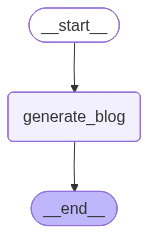

In [10]:
workflow = StateGraph(BlogState)

# Add Note
workflow.add_node("generate_blog", generate_blog)

workflow.add_edge(START, "generate_blog")
workflow.add_edge("generate_blog", END)

chain=workflow.compile()

display(Image(chain.get_graph().draw_mermaid_png()))

In [11]:
# Initial input
inputs = {"topic": "Blog about Langgraph"}

# Run the graph
final_state = chain.invoke(inputs)

# Get the result from your state key
print(final_state["final_blog"])

Here is a comprehensive, engaging blog post about LangGraph that you can use for your website, Medium, or Dev.to platform.

***

# Beyond Linear LLMs: Building Reliable, Stateful AI Agents with LangGraph

If you’ve spent any time building generative AI applications over the past year, you are probably intimately familiar with **LangChain**. It revolutionized how we build AI apps by allowing us to string together prompts, retrievers, and LLMs into neat, linear workflows called *chains*.

But as AI applications have matured, developers have hit a wall. Linear chains are great for simple tasks (like basic RAG), but they fail when tasked with complex, autonomous workflows. What happens if the AI needs to correct its own mistake? What if it needs to loop back, ask the user a question, and try again?

Chains can’t do loops. Enter **LangGraph**.

In this post, we’ll explore what LangGraph is, why it represents the next step in AI agent architecture, and how it can help you build smarter, more